## Clean dataset.csv file

In [19]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

Pour les visualisations et le nettoyage du fichier `.csv`, nous aurons besoin des fonctions de trois **librairies** externes.

---

Les imports utilisés sont :

- `import pandas as pd` : librairie de manipulation de données tabulaires. L'acronyme `pd` évite d'écrire `pandas` à chaque utilisation, rendant le code plus lisible.
- `from matplotlib import pyplot as plt` : module de création de graphiques. Importé directement depuis `matplotlib` avec l'alias `plt` pour alléger l'écriture.
- `import seaborn as sns` : librairie de visualisation statistique construite sur matplotlib, qui simplifie la création de graphiques plus élaborés. L'alias `sns` est la convention standard.

In [20]:
df = pd.read_csv(
    "dataset.csv", sep=";", engine="python", encoding="utf-8", encoding_errors="replace"
)

Cette étape charge le fichier nettoyé en mémoire sous forme de **DataFrame pandas**, la structure de données tabulaire qui sera manipulée dans toutes les étapes suivantes.

---

Le fichier `dataset.csv` est lu avec `pd.read_csv()`. Les paramètres utilisés sont :

- `sep=";"` : le séparateur de colonnes est un point-virgule (format CSV français)
- `engine="python"` : moteur de lecture plus robuste, qui gère mieux les cas limites
- `encoding="utf-8"` : encodage attendu du fichier
- `encoding_errors="replace"` : les caractères illisibles sont remplacés plutôt que de faire planter la lecture

---


In [21]:
comment_cols = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]

df.drop(columns=comment_cols, inplace=True)

Cette étape **supprime les colonnes de commentaires textuels** du DataFrame, qui ne seront pas utilisées dans l'analyse.

---

Les trois colonnes supprimées sont :

- `"Cancellation comments"` : commentaires liés aux annulations de trains
- `"Departure delay comments"` : commentaires liés aux retards au départ
- `"Arrival delay comments"` : commentaires liés aux retards à l'arrivée

---

Ces colonnes contiennent du texte libre, souvent incomplet ou non structuré, et n'apportent pas de valeur exploitable pour une analyse quantitative. Elles sont supprimées avec `df.drop(columns=..., inplace=True)` pour alléger le DataFrame.

---

In [22]:
df = df[df["Date"].notna()]


def normalize_date(val):
    if pd.isna(val):
        return None
    val = str(val).strip()
    for sep in [" ", "/"]:
        val = val.replace(sep, "-")
    parts = val.split("-")
    if len(parts) != 2:
        return None
    a, b = parts[0].strip(), parts[1].strip()
    if len(a) == 4 and len(b) == 2:
        return f"{a}-{b}"
    elif len(a) == 2 and len(b) == 4:
        return f"{b}-{a}"
    return None


df["Date"] = df["Date"].apply(normalize_date)
df["Date"] = df["Date"].ffill()
df.insert(1, "Month", df["Date"].str[-2:])
df.insert(0, "Year", df["Date"].str[:4])
df = df.drop("Date", axis=1)
df = df.sort_values(by=["Year", "Month"])

Cette étape **uniformise le format des dates** présentes dans la colonne `Date`, qui contient plusieurs formats différents selon les lignes (`2018-01`, `2018 01`, `01/2018`, `2018/01`, etc.).

---

La fonction `normalize_date()` traite chaque valeur individuellement :

- Si la valeur est nulle, elle retourne `None`
- Elle remplace les séparateurs alternatifs (espace, `/`) par des tirets `-`
- Elle découpe la valeur en deux parties autour du tiret
- Si la première partie fait 4 chiffres (année), le format est `YYYY-MM` → conservé tel quel
- Si la première partie fait 2 chiffres (mois), le format est `MM-YYYY` → inversé en `YYYY-MM`
- Si le découpage ne donne pas exactement 2 parties, la valeur est considérée invalide et retourne `None`

---

Une fois la fonction appliquée, les dates qui n'ont pas pu être parsées (retournées `None`) sont **comblées par la valeur de la ligne précédente** grâce à `ffill()` (forward-fill). Cette logique est valide car les lignes sont ordonnées chronologiquement et les valeurs nulles appartiennent au même bloc temporel que leur voisine.

---

La colonne `Date` normalisée est ensuite **séparée en deux colonnes distinctes** insérées en tête du DataFrame :

- `Year` : insérée en position 0, extraite des 4 premiers caractères (`str[:4]`)
- `Month` : insérée en position 1, extraite des 2 derniers caractères (`str[-2:]`)

La colonne `Date` originale est alors supprimée avec `df.drop()`. Le DataFrame est enfin **trié chronologiquement** par `Year` puis `Month` avec `sort_values()`.

---

In [23]:
text_cols = ["Date", "Service", "Departure station", "Arrival station"]
pct_cols = [col for col in df.columns if col.startswith("Pct")]
numeric_cols = [
    col for col in df.columns if col not in text_cols and col not in pct_cols
]

for col in numeric_cols + pct_cols:
    df[col] = pd.to_numeric(
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False),
        errors="coerce",
    )

int_cols = [col for col in numeric_cols if "Number" in col]
for col in int_cols:
    df[col] = df[col].round().astype("Int64")

Cette étape **convertit toutes les colonnes numériques** vers les bons types Python, en corrigeant les problèmes de format rencontrés dans le dataset.

---

Les colonnes sont d'abord réparties en deux catégories :

- `text_cols` : colonnes texte obligatoires (`Date`, `Service`, `Departure station`, `Arrival station`)
- `pct_cols` : colonnes de pourcentages (celles dont le nom commence par `Pct`)
- `numeric_cols` : toutes les autres colonnes (comptages, délais moyens)

---

Pour chaque colonne numérique et de pourcentage, trois transformations sont appliquées avant conversion :

- `.str.strip()` : supprime les espaces en début et fin de valeur
- `.str.replace(",", ".")` : corrige les virgules décimales par des points (`5,04` → `5.04`)
- `.str.replace(" ", "")` : supprime les espaces parasites à l'intérieur des nombres

La conversion finale est faite avec `pd.to_numeric(..., errors="coerce")` : toute valeur qui ne peut pas être convertie en nombre devient `NaN` plutôt que de faire planter le programme.

---

Les colonnes de **comptage de trains** (celles dont le nom contient `Number`) sont ensuite arrondies et converties en `Int64`, le type entier nullable de pandas, pour éviter l'affichage de `.0` inutiles tout en supportant les valeurs manquantes.

---

In [24]:
def impute_pct_row(row):
    vals = row[pct_cols]
    null_val = vals.isna()
    if null_val.sum() == 1:
        row[pct_cols[null_val.argmax()]] = round(100 - vals.sum(), 6)
    return row


df = df.apply(impute_pct_row, axis=1)

Cette étape **récupère les lignes avec un seul pourcentage manquant** parmi les 6 colonnes `Pct`, en déduisant sa valeur mathématiquement.

---

Les 6 colonnes `Pct delay due to ...` représentent la répartition des causes de retard. Leur somme doit être égale à **100**. Si une seule valeur est manquante, elle se calcule donc par :

```
valeur_manquante = 100 - somme_des_cinq_autres
```

La fonction `impute_pct_row()` est appliquée ligne par ligne. Elle vérifie d'abord le nombre de valeurs nulles dans les colonnes `Pct` :

- Si exactement **1 valeur est nulle** → elle est calculée et remplie
- Si **0 ou 2+ valeurs sont nulles** → la ligne est laissée telle quelle (sera supprimée à l'étape 9 si les nulls persistent)

---

In [25]:
invalid_values = {
    "NC",
    "N/C",
    "NON COMMUNIQUE",
    "NON COMMUNIQUÉ",
    "Non communiqué",
    "Non communique",
    "NAN",
    "NA",
    "N/A",
    "-",
    "",
}


def is_invalid(val):
    if pd.isna(val):
        return True
    return str(val).strip().upper() in invalid_values


for col in ["Service", "Departure station", "Arrival station"]:
    df = df[~df[col].apply(is_invalid)]

Cette étape **identifie et supprime les lignes** dont les colonnes obligatoires contiennent des valeurs explicitement marquées comme non renseignées, qu'il s'agisse de vrais `NaN` ou de chaînes de caractères conventionnelles.

---

L'ensemble `invalid_values` regroupe toutes les formes rencontrées dans le dataset pour signifier une absence de valeur :

- `"NC"`, `"N/C"` : abréviations françaises de "Non Communiqué"
- `"NON COMMUNIQUE"`, `"NON COMMUNIQUÉ"` : forme longue
- `"Non communiqué"`, `"Non communique"` : forme longue minuscule
- `"NAN"`, `"NA"`, `"N/A"` : formes anglaises
- `"-"` : tiret utilisé comme placeholder
- `""` : chaîne vide

---

La fonction `is_invalid()` retourne `True` si la valeur est nulle **ou** si elle figure dans cet ensemble (après mise en majuscules et suppression des espaces). Elle est appliquée sur les quatre colonnes obligatoires : `Date`, `Service`, `Departure station`, `Arrival station`. Toute ligne contenant une valeur invalide dans l'une de ces colonnes est supprimée.

---

In [26]:
ACCENTS = str.maketrans(
    "ÀÁÂÃÄÅÈÉÊËÌÍÎÏÒÓÔÕÖÙÚÛÜÝŸÑÇàáâãäåèéêëìíîïòóôõöùúûüýÿñç",
    "AAAAAAEEEEIIIIOOOOOUUUUYYNCaaaaaaeeeeiiiioooooUUUUYYNC",
)


def normalize(s):
    if not s or str(s).strip() == "":
        return ""
    return str(s).strip().upper().translate(ACCENTS).replace("-", " ").replace("'", " ")


def to_final(s):
    if not s or str(s).strip() == "":
        return ""
    return str(s).strip().upper().translate(ACCENTS)


gares = pd.read_csv("data/name_reference.csv", sep=";", encoding="utf-8-sig")
gares["norm"] = gares["Nom_Gare"].apply(normalize)
gares["final"] = gares["Nom_Gare"].apply(to_final)
norm_to_final = dict(zip(gares["norm"], gares["final"]))

manual_map = {
    "ANGERS ST LAUD": "ANGERS SAINT-LAUD",
    "BORDEAUX ST JEAN": "BORDEAUX SAINT-JEAN",
    "MARSEILLE ST CHARLES": "MARSEILLE SAINT-CHARLES",
    "ST ETIENNE CHATEAUCREUX": "SAINT-ETIENNE CHATEAUCREUX",
    "ST MALO": "SAINT-MALO",
    "ST PIERRE DES CORPS": "SAINT-PIERRE-DES-CORPS",
    "CHAMBERY CHALLES LES EAUX": "CHAMBERY - CHALLES-LES-EAUX",
    "DIJON VILLE": "DIJON",
    "LA ROCHELLE VILLE": "LA ROCHELLE",
    "LE CREUSOT MONTCEAU MONTCHANIN": "LE CREUSOT - MONTCEAU-LES-MINES - MONTCHANIN TGV",
    "MACON LOCHE": "MACON LOCHE TGV",
    "MARNE LA VALLEE": "MARNE-LA-VALLEE CHESSY",
    "MONTPELLIER": "MONTPELLIER SAINT-ROCH",
    "MULHOUSE VILLE": "MULHOUSE",
    "NICE VILLE": "NICE",
    "PARIS LYON": "PARIS GARE DE LYON",
    "PARIS NORD": "PARIS GARE DU NORD",
    "PARIS VAUGIRARD": "PARIS VAUGIRARD",
    "VALENCE ALIXAN TGV": "VALENCE TGV RHONE-ALPES SUD",
    "BELLEGARDE (AIN)": "BELLEGARDE-SUR-VALSERINE",
    "LILLE": "LILLE FLANDRES",
    "BARCELONA": "BARCELONA",
    "FRANCFORT": "FRANCFORT",
    "GENEVE": "GENEVE",
    "LAUSANNE": "LAUSANNE",
    "MADRID": "MADRID",
    "STUTTGART": "STUTTGART",
    "ZURICH": "ZURICH",
    "ITALIE": "ITALIE",
    "0": None,
}


def fix_station(val):
    if pd.isna(val):
        return None
    norm = normalize(val)
    if norm in manual_map:
        return manual_map[norm]
    if norm in norm_to_final:
        return norm_to_final[norm]


df["Departure station"] = df["Departure station"].apply(fix_station)
df["Arrival station"] = df["Arrival station"].apply(fix_station)

Cette étape **valide et corrige les noms des gares** en les comparant au référentiel officiel SNCF, en mettant tout en majuscules sans accents des deux côtés pour que la comparaison soit fiable.

---

La table `ACCENTS` associe chaque lettre accentuée à son équivalent sans accent. `str.maketrans()` prend deux chaînes de même longueur et associe chaque caractère de la première à celui en face dans la deuxième. La variable est en majuscules par convention pour signaler que c'est une constante.

La fonction `normalize()` produit la **forme canonique** d'un nom, uniquement utilisée pour la comparaison, pas pour le stockage. Elle met le texte en majuscules, supprime les accents via `.translate(ACCENTS)`, et remplace les tirets et apostrophes par des espaces. Ainsi `"Bordeaux Saint-Jean"` et `"BORDEAUX ST JEAN"` deviennent comparables.

La fonction `to_final()` produit la **forme finale stockée**. Identique à `normalize()` mais sans remplacer les tirets et apostrophes, pour conserver la ponctuation du nom officiel. `"Bordeaux Saint-Jean"` devient `"BORDEAUX SAINT-JEAN"` et non `"BORDEAUX SAINT JEAN"`.

---

Le fichier `name-reference.csv` est chargé avec `utf-8-sig`, comme UTF-8 mais qui gère en plus le BOM, un marqueur invisible qu'Excel ou Windows ajoute parfois au début des fichiers et qui peut corrompre la première colonne. Les deux fonctions sont appliquées sur la colonne `Nom_Gare` pour créer deux nouvelles colonnes : `norm` pour la comparaison, `final` pour le stockage. Le dictionnaire `norm_to_final` associe ensuite chaque forme canonique à sa forme finale.

---

`manual_map` est un dictionnaire de **corrections manuelles** pour les cas que la correspondance automatique ne peut pas résoudre, principalement les abréviations (`ST` au lieu de `SAINT`), les noms raccourcis, et les gares étrangères absentes du référentiel SNCF. Les clés sont en forme canonique, les valeurs sont les formes finales corrigées. Les entrées mappées sur `None` (`ITALIE`, `0`) sont des valeurs invalides, leur ligne sera supprimée à l'étape suivante.

---

La fonction `fix_station()` est appliquée sur chaque cellule des colonnes `Departure station` et `Arrival station` :

- Si la valeur est nulle, elle retourne `None`
- Elle normalise le nom en forme canonique
- Elle cherche d'abord dans `manual_map`, les corrections manuelles ont la priorité
- Sinon elle cherche dans `norm_to_final`, la correspondance automatique contre le référentiel
- Si aucune correspondance n'est trouvée, elle retourne implicitement `None` et la ligne sera supprimée à l'étape 9

In [27]:
df = df[df["Service"].isin(["National", "International"])]

Cette étape **supprime les lignes dont la colonne `Service` ne correspond pas** aux deux valeurs attendues dans le dataset.

---

Seules deux valeurs sont considérées valides : `"National"` et `"International"`. Toute ligne contenant une autre valeur (vide, mal formatée, ou non reconnue) est supprimée avec `isin()`.

---

In [28]:
df[df["Service"].isin(["National"])].to_csv(
    "data/dataset_nation.csv", sep=";", index=False, encoding="utf-8"
)
df[df["Service"].isin(["International"])].to_csv(
    "data/dataset_international.csv", sep=";", index=False, encoding="utf-8"
)

Cette étape **Sépare en deux tableaux différents** les différents `Services`.

---

- Pour `dataset_nation.csv` : Seul les entrées`"National"` sont gardés avec `isin()`.
- Pour `dataset_internation.csv` : Seul les entrées`"International"` sont gardés avec `isin()`.

---

In [29]:
df["Pct delay due to external causes"] = (
    df["Pct delay due to external causes"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Pct delay due to infrastructure"] = (
    df["Pct delay due to infrastructure"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Pct delay due to traffic management"] = (
    df["Pct delay due to traffic management"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Pct delay due to rolling stock"] = (
    df["Pct delay due to rolling stock"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Pct delay due to station management and equipment reuse"] = (
    df["Pct delay due to station management and equipment reuse"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Pct delay due to passenger handling (crowding, disabled persons, connections)"] = (
    df["Pct delay due to passenger handling (crowding, disabled persons, connections)"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Average delay of late trains at departure"] = (
    df["Average delay of late trains at departure"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Average delay of all trains at departure"] = (
    df["Average delay of all trains at departure"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Average delay of late trains at arrival"] = (
    df["Average delay of late trains at arrival"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Average delay of trains > 15min (if competing with flights)"] = (
    df["Average delay of trains > 15min (if competing with flights)"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)
df["Average delay of all trains at arrival"] = (
    df["Average delay of all trains at arrival"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
    .round(2)
)

Cette étape **normalise et arrondit les colonnes de pourcentages et de délais moyens** à deux décimales.

---

Deux types de problèmes de format sont corrigés avant conversion :

- La virgule décimale (`,`) est remplacée par un point (`.`) pour compatibilité Python
- Le symbole `%` éventuel est supprimé pour permettre la conversion en `float`

---

Les colonnes traitées sont les six colonnes `Pct delay due to ...` (répartition des causes de retard) ainsi que les cinq colonnes `Average delay of ...` (délais moyens en minutes). Toutes sont arrondies à **2 décimales** avec `.round(2)` pour homogénéiser la précision numérique du dataset.

---

In [30]:
df = df.dropna(subset=["Service", "Departure station", "Arrival station"])
df = df.dropna(subset=numeric_cols)
df = df[df[pct_cols].isna().sum(axis=1) == 0]

Cette étape **supprime toutes les lignes restantes qui contiennent encore des valeurs manquantes** après les tentatives de correction et d'imputation des étapes précédentes.

---

Les suppressions sont effectuées en trois passes :

- `dropna(subset=[...])` sur les colonnes texte obligatoires (`Date`, `Service`, `Departure station`, `Arrival station`) : élimine les lignes dont une gare ou une date n'a pas pu être corrigée
- `dropna(subset=numeric_cols)` : élimine les lignes avec au moins une valeur numérique manquante parmi les colonnes de comptage et de délais
- Filtre sur `pct_cols` : élimine les lignes ayant encore au moins un pourcentage nul (c'est-à-dire celles qui avaient 2+ valeurs `Pct` manquantes, non récupérables à l'étape 5)

---

In [31]:
df.to_csv("cleaned_dataset.csv", sep=";", index=False, encoding="utf-8")

Cette étape **exporte le DataFrame nettoyé** vers un fichier CSV final.

---

`df.to_csv()` est utilisé avec les paramètres suivants :

- `sep=";"` : même séparateur que le fichier source (format CSV français)
- `index=False` : l'index pandas (numéro de ligne) n'est pas écrit dans le fichier
- `encoding="utf-8"` : encodage UTF-8 pour conserver les caractères spéciaux

Le fichier produit est `dataset_clean.csv`, prêt à l'utilisation.

Cette étape **charge le dataset nettoyé** et affiche la répartition des trains entre services nationaux et internationaux sous forme de **graphique camembert**.

---

Le fichier `cleaned_dataset.csv` est rechargé avec `pd.read_csv()` pour partir d'un DataFrame propre en vue des visualisations.

Les deux valeurs comptées sont :

- `"National"` : nombre de lignes correspondant à des trajets nationaux
- `"International"` : nombre de lignes correspondant à des trajets internationaux

`plt.pie()` génère le graphique avec les labels `y` et les couleurs `yellow` et `black`. `plt.show()` affiche le résultat.


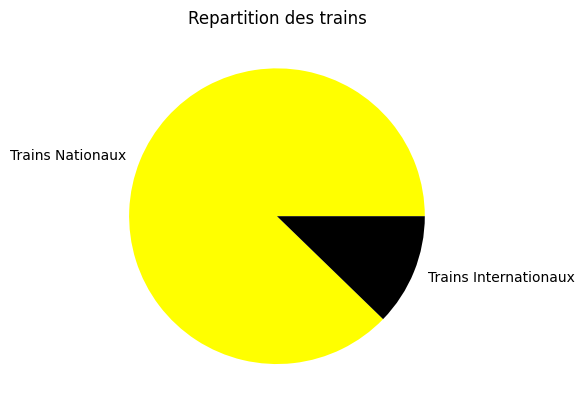

In [32]:
df = pd.read_csv(
    "cleaned_dataset.csv",
    sep=";",
    engine="python",
    encoding="utf-8",
    encoding_errors="replace",
)
x = (
    df["Service"].isin(["National"]).sum(),
    df["Service"].isin(["International"]).sum(),
)
y = ["Trains Nationaux", "Trains Internationaux"]
plt.title("Repartition des trains")
plt.pie(x, labels=y, colors=["yellow", "black"])
plt.show()

Cette étape **visualise le nombre de trains effectivement circulés par année**, en soustrayant les trains annulés aux trains prévus.

---

Deux agrégations annuelles sont calculées avec `groupby("Year")` :

- `y1` : somme de `"Number of scheduled trains"` (trains prévus)
- `y2` : somme de `"Number of cancelled trains"` (trains annulés)

Le résultat `result = y1 - y2` représente le nombre de trains ayant réellement circulé chaque année.

`plt.bar()` génère un histogramme avec les années en abscisse et le nombre de trains en ordonnée.


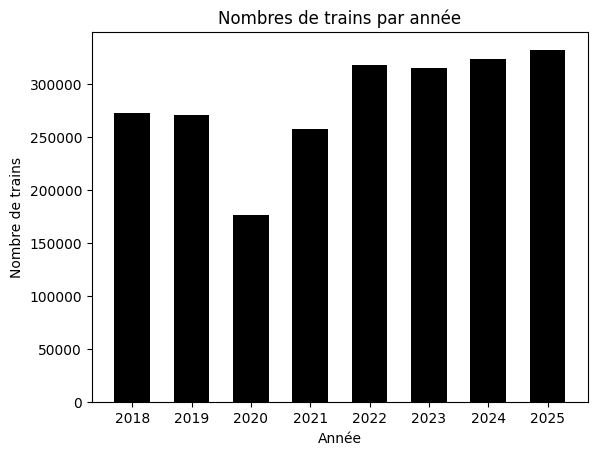

In [33]:
y1 = df.groupby("Year")["Number of scheduled trains"].sum()
y2 = df.groupby("Year")["Number of cancelled trains"].sum()

x = y1.index
result = y1 - y2

plt.title("Nombres de trains par année")
plt.bar(x, result, color="black", width=0.6)
plt.xlabel("Année")
plt.ylabel("Nombre de trains")
plt.show()

Cette étape **visualise l'évolution du nombre de trains en retard à l'arrivée** par année sous forme de courbe.

---

Le nombre total de trains en retard est agrégé par année avec `groupby("Year")` et `reset_index()` pour obtenir un DataFrame compatible avec seaborn.

`sns.lineplot()` est utilisé avec les paramètres suivants :

- `x="Year"` / `y="Number of trains delayed at arrival"` : axes du graphique
- `marker="o"` : un point est affiché à chaque année pour faciliter la lecture
- `color="black"` : couleur de la courbe

`plt.tight_layout()` ajuste les marges pour éviter les chevauchements avant l'affichage.

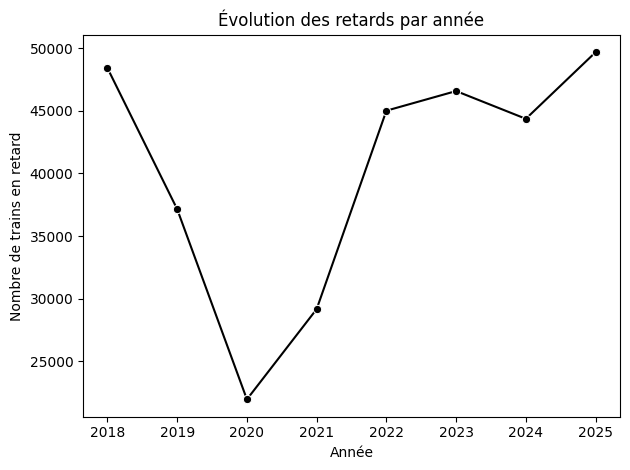

In [34]:
retards_par_an = (
    df.groupby("Year")["Number of trains delayed at arrival"].sum().reset_index()
)

sns.lineplot(
    x="Year",
    y="Number of trains delayed at arrival",
    data=retards_par_an,
    marker="o",
    color="black",
)
plt.title("Évolution des retards par année")
plt.xlabel("Année")
plt.ylabel("Nombre de trains en retard")
plt.tight_layout()
plt.show()

Cette étape **visualise l'évolution du nombre de trains en retard à l'arrivée** par année sous forme de courbe.

---

Le nombre total de trains en retard est d'abord agrégé par année avec `groupby("Year")`, puis `reset_index()` est appelé pour obtenir un DataFrame tabulaire compatible avec seaborn.

`sns.lineplot()` est utilisé avec les paramètres suivants :

- `x="Year"` / `y="Number of trains delayed at arrival"` : axes du graphique
- `marker="o"` : un point est affiché à chaque année pour faciliter la lecture
- `color="black"` : couleur de la courbe

`plt.tight_layout()` ajuste automatiquement les marges pour éviter tout chevauchement entre les éléments du graphique avant l'affichage.